# VisionDrive3D — Model Inference Demo
Load fine-tuned detection and segmentation checkpoints
and run inference on held-out test images.

In [1]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

PROJECT_ROOT = Path('..').resolve()
DATASET_ROOT = PROJECT_ROOT / 'output_dataset'
DET_CKPT  = PROJECT_ROOT / 'runs/detect/yolov8n_finetuned/weights/best.pt'
SEG_CKPT  = PROJECT_ROOT / 'runs/seg/yolov8n_seg_finetuned/weights/best.pt'

assert DET_CKPT.exists(), f"Detection checkpoint not found: {DET_CKPT}"
assert SEG_CKPT.exists(), f"Segmentation checkpoint not found: {SEG_CKPT}"
print("Checkpoints found. Figures will be shown inline (no files saved).")

Checkpoints found. Figures will be shown inline (no files saved).


In [2]:
det_model = YOLO(str(DET_CKPT))
seg_model = YOLO(str(SEG_CKPT))
print(f"Detection model:    {DET_CKPT.name}")
print(f"Segmentation model: {SEG_CKPT.name}")

Detection model:    best.pt
Segmentation model: best.pt


In [3]:
test_images = sorted((DATASET_ROOT / 'images' / 'test').glob('*.png'))[:6]
print(f"Running inference on {len(test_images)} test images:")
for p in test_images:
    print(f"  {p.name}")

Running inference on 6 test images:
  scene_00003.png
  scene_00012.png
  scene_00013.png
  scene_00015.png
  scene_00016.png
  scene_00044.png


/home/ml4u/BKTeam/ChiDai/VisionDrive3D/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


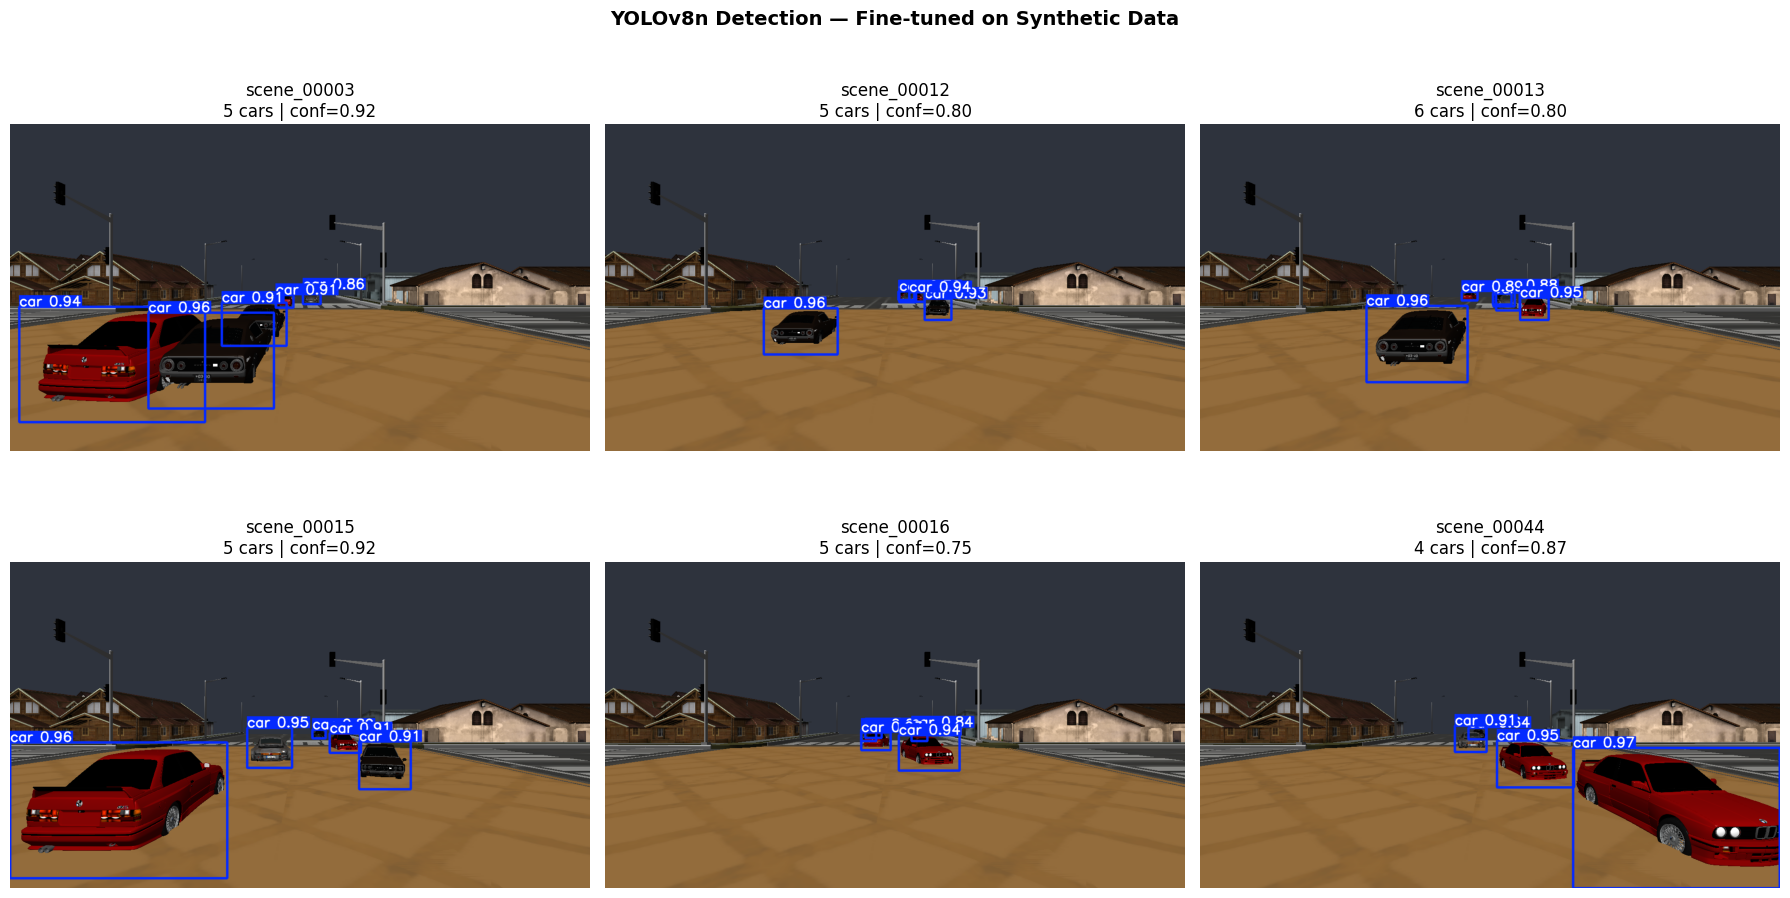

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLOv8n Detection — Fine-tuned on Synthetic Data',
             fontsize=14, fontweight='bold')

for idx, img_path in enumerate(test_images):
    ax = axes[idx // 3][idx % 3]
    results = det_model(str(img_path), verbose=False)
    res = results[0]
    annotated_rgb = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_rgb)
    n_det = len(res.boxes) if res.boxes is not None else 0
    confs = [float(b.conf) for b in res.boxes] if res.boxes else []
    mean_conf = np.mean(confs) if confs else 0.0
    ax.set_title(f'{img_path.stem}\n{n_det} cars | conf={mean_conf:.2f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

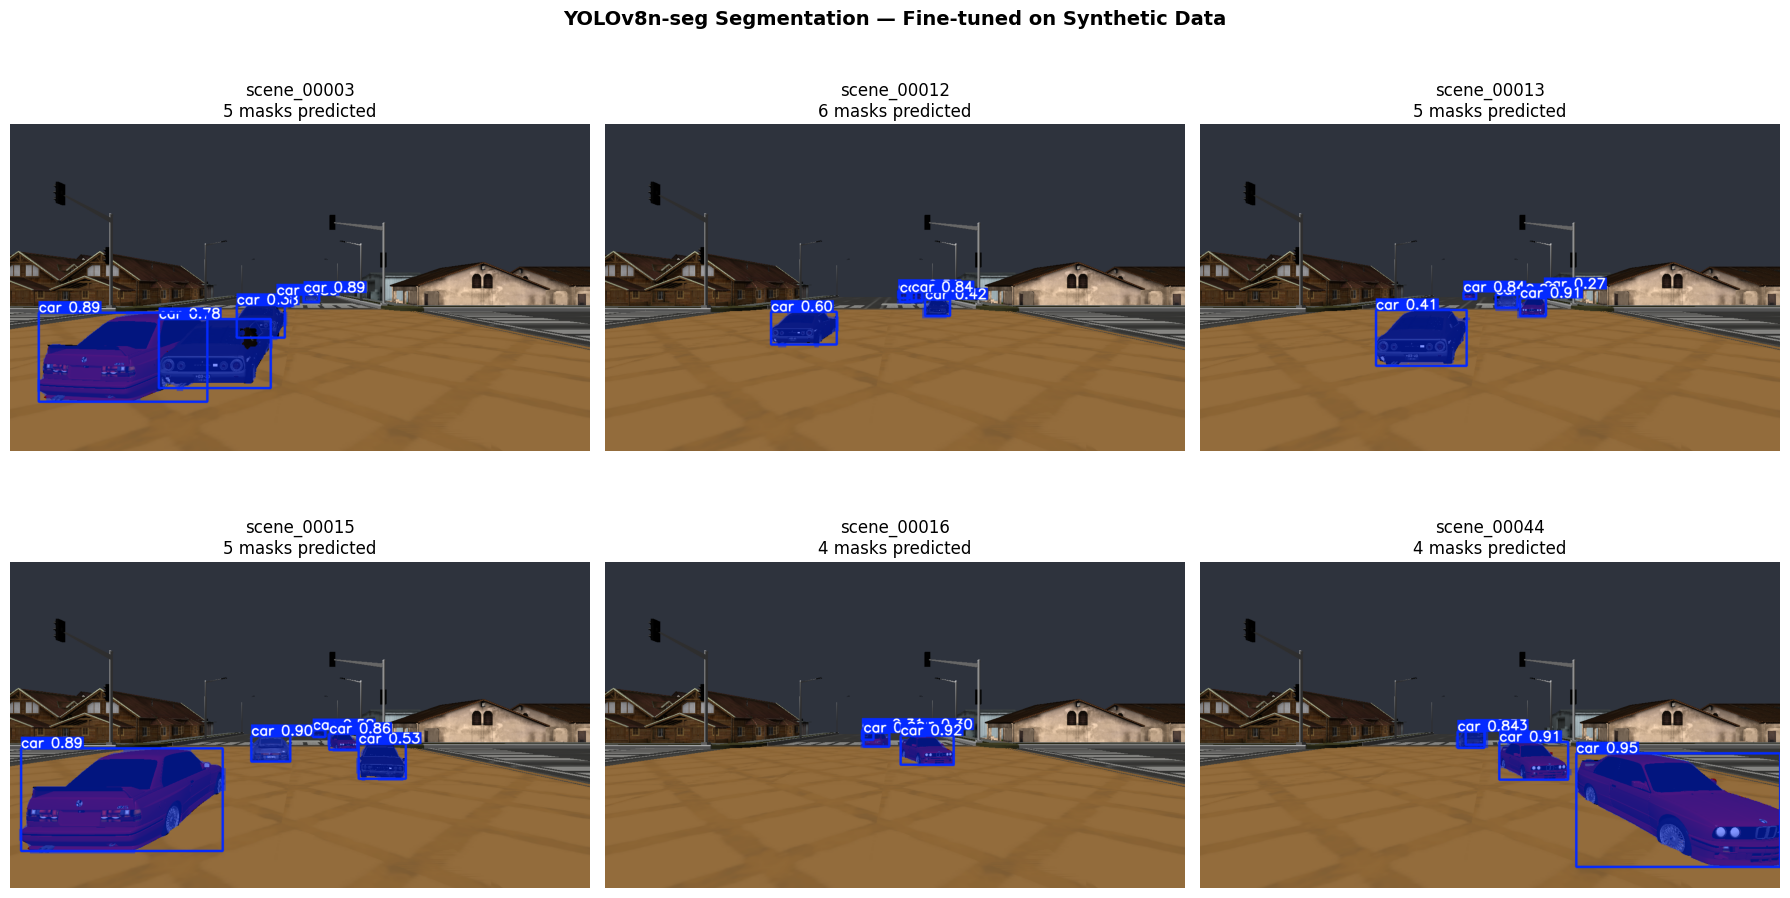

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLOv8n-seg Segmentation — Fine-tuned on Synthetic Data',
             fontsize=14, fontweight='bold')

for idx, img_path in enumerate(test_images):
    ax = axes[idx // 3][idx % 3]
    results = seg_model(str(img_path), verbose=False)
    res = results[0]
    annotated_rgb = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_rgb)
    n_masks = len(res.masks) if res.masks is not None else 0
    ax.set_title(f'{img_path.stem}\n{n_masks} masks predicted')
    ax.axis('off')

plt.tight_layout()
plt.show()

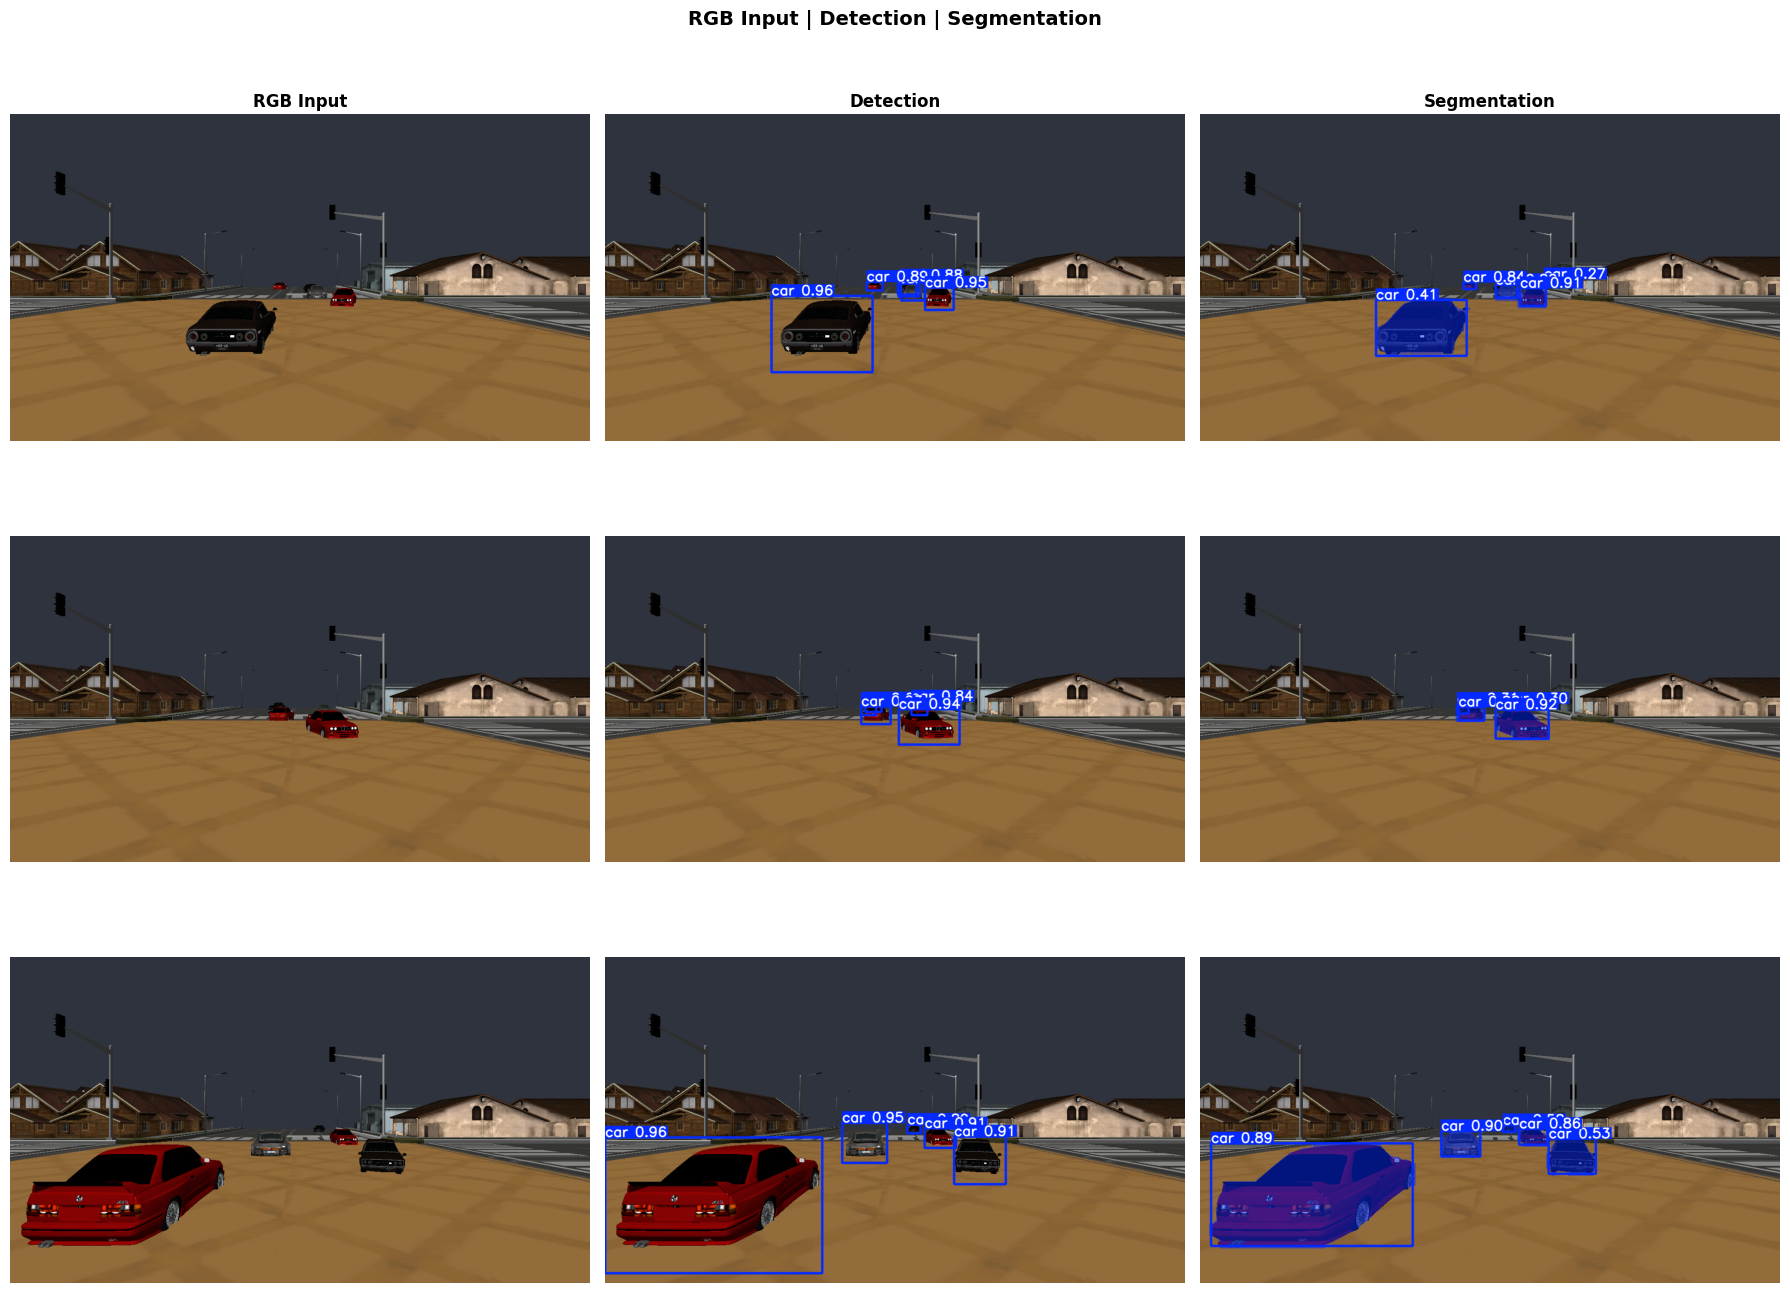

In [6]:
# Pick 3 scenes with most detections
scored = []
for img_path in test_images:
    r = det_model(str(img_path), verbose=False)[0]
    scored.append((len(r.boxes) if r.boxes else 0, img_path))
scored.sort(reverse=True)
best_3 = [p for _, p in scored[:3]]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('RGB Input | Detection | Segmentation',
             fontsize=14, fontweight='bold')
for col, title in enumerate(['RGB Input', 'Detection', 'Segmentation']):
    axes[0][col].set_title(title, fontsize=12, fontweight='bold')

for row, img_path in enumerate(best_3):
    img_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    axes[row][0].imshow(img_rgb)
    axes[row][0].set_ylabel(img_path.stem, fontsize=9)
    axes[row][0].axis('off')

    det_ann = cv2.cvtColor(
        det_model(str(img_path), verbose=False)[0].plot(), cv2.COLOR_BGR2RGB)
    axes[row][1].imshow(det_ann)
    axes[row][1].axis('off')

    seg_ann = cv2.cvtColor(
        seg_model(str(img_path), verbose=False)[0].plot(), cv2.COLOR_BGR2RGB)
    axes[row][2].imshow(seg_ann)
    axes[row][2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
results_path = DATASET_ROOT / 'results.json'
if results_path.exists():
    with open(results_path) as f:
        results = json.load(f)
    print('=' * 55)
    print(f"{'Model':<28} {'mAP@50':>8} {'mAP@50-95':>10}")
    print('=' * 55)
    for task in ['detection', 'segmentation']:
        if task in results:
            for variant in ['baseline', 'finetuned']:
                if variant in results[task]:
                    m = results[task][variant]
                    name = f"YOLOv8n-{'seg ' if task=='segmentation' else ''}{variant}"
                    print(f"{name:<28} {m.get('mAP50',0):>8.3f} {m.get('mAP50_95',0):>10.3f}")
    print('=' * 55)
else:
    print("results.json not found — run evaluate.py first")
    print("Showing live validation metrics...")
    det_metrics = det_model.val(
        data=str(DATASET_ROOT / 'dataset.yaml'), split='test', verbose=False)
    print(f"Detection mAP@50:    {det_metrics.box.map50:.3f}")
    print(f"Detection mAP@50-95: {det_metrics.box.map:.3f}")

results.json not found — run evaluate.py first
Showing live validation metrics...
Ultralytics 8.4.42 🚀 Python-3.12.8 torch-2.11.0+cu130 CPU (Intel Core i7-14700K)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3735.0±758.2 MB/s, size: 276.6 KB)
val: Scanning /home/ml4u/BKTeam/ChiDai/VisionDrive3D/output_dataset/labels/test.cache... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 11.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.7it/s 1.5s0.7s
                   all         50        250       0.95      0.944      0.968      0.818
Speed: 0.5ms preprocess, 20.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/ml4u/BKTeam/ChiDai/VisionDrive3D/notebooks/runs/detect/val-4
Detection mAP@50:    0.968
Detection mAP@50-95: 0.818


In [8]:
import time

img_path = str(test_images[0])
times = []
for i in range(25):
    t0 = time.perf_counter()
    det_model(img_path, verbose=False)
    times.append((time.perf_counter() - t0) * 1000)

warmup_skipped = times[5:]
print(f"Detection inference speed:")
print(f"  Mean:   {np.mean(warmup_skipped):.1f} ms/image")
print(f"  Median: {np.median(warmup_skipped):.1f} ms/image")
print(f"  FPS:    {1000/np.mean(warmup_skipped):.1f}")

Detection inference speed:
  Mean:   29.5 ms/image
  Median: 29.3 ms/image
  FPS:    33.9
